In [87]:
import ast
import glob
import warnings
from collections import defaultdict
from datetime import date

import numpy as np
import pandas as pd
import wandb

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import os
import json


today = date.today()
api = wandb.Api()

# # Find all csv files in the current directory
csv_files = glob.glob("csv/*.csv")
# # Collect all the names of the csv files without the extension
csv_names = [csv_file[:-4] for csv_file in csv_files]
project_name = "6g_4rd_September"  
user = "telyatnikov_sap"

if project_name not in csv_names:
    runs = api.runs(f"{user}/{project_name}")

    summary_list, config_list, name_list = [], [], []
    for run in runs:
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)

        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k, v in run.config.items() if not k.startswith("_")}
        )

        # .name is the human-readable name of the run.
        name_list.append(run.name)

    runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

    runs_df.to_csv(f"csv/{user}_{project_name}.csv")
else:
    runs_df = pd.read_csv(f"csv/{user}_{project_name}.csv", index_col=0)

    for row in runs_df.iloc:
        row["summary"] = ast.literal_eval(row["summary"])
        row["config"] = ast.literal_eval(row["config"])


for row in runs_df.iloc:
    row["summary"].update(row["config"])

lst = [i["summary"] for i in runs_df.iloc]
df = pd.DataFrame.from_dict(lst)

df_init = df.copy()

# drop row 0
#df = df.drop(df.index[-1])

In [88]:
def normalize_column(df, column_to_normalize):
    # Use json_normalize to flatten the nested dictionaries into separate columns
    flattened_df = pd.json_normalize(df[column_to_normalize])
    # Rename columns to include 'nested_column' prefix
    flattened_df.columns = [
        f"{column_to_normalize}.{col}" for col in flattened_df.columns
    ]
    # Concatenate the flattened DataFrame with the original DataFrame
    result_df = pd.concat([df, flattened_df], axis=1)
    # Get new columns names
    new_columns = flattened_df.columns
    # Drop the original nested column if needed
    result_df.drop(column_to_normalize, axis=1, inplace=True)
    return result_df, new_columns


# Config columns to normalize
columns_to_normalize = ["decoder", 'compressor']
# df.fillna('NA', inplace=True)
# df = df[df['test/loss'] != 'NA']
# Keep track of config columns added
config_columns = []
for column in columns_to_normalize:
    df, columns = normalize_column(df, column)
    config_columns.extend(columns)



# substitute NaN with 'NA'
df.fillna('NA', inplace=True)
df = df[df['Elements compression'] != 'NA']
df = df[df['compressor.name'] != 'NA'] 
df['compressor.r'] = df['compressor.r'].apply(lambda x: str(x))
df['Elements compression'] = df['Elements compression'].apply(lambda x: np.round((1 - x)*100))
# Rename No Compression to VIT

# First rename conditional cases: 
df.loc[(df['compressor.name'] == 'AE') & (df['reconstruct_images'] == False), 'compressor.name'] = 'AC'


#df.loc[(df['compressor.name'] == 'Tome+AE')  & (df['compressor.r'] == '[0, 0, 0, 0, 0, 0]') & (df['reconstruct_images'] == False), 'compressor.name'] = 'VAC'
#df.loc[(df['compressor.name'] == 'Tome+AE')  & (df['compressor.r'] == '[0, 0, 0, 0, 0, 0]') & (df['reconstruct_images'] == True), 'compressor.name'] = 'VACR'

# Second rename conditional cases: 
df.loc[(df['compressor.name'] == 'Tome+AE') & (df['reconstruct_images'] == False), 'compressor.name'] = 'TAC'

df.loc[(df['compressor.name'] == 'Tome+AE') & (df['reconstruct_images'] == True), 'compressor.name'] = 'TACR'

# Baselines
df.loc[(df['compressor.name'] == 'Tome') & (df['compressor.r'] == '[0, 0, 0, 0, 0, 0]') & (df['reconstruct_images'] == False), 'compressor.name'] = 'VC'
df.loc[(df['compressor.name'] == 'Tome') & (df['compressor.r'] == '[0, 0, 0, 0, 0, 0]') & (df['reconstruct_images'] == True), 'compressor.name'] = 'VCR'





rename_dict = {
    'No Compression': 'VIT',
    'Tome':'TCR', 
    'AE':'ACR', 
    'Tome+onlyclassifier':'TC'
}

df['compressor.name'] = df['compressor.name'].apply(lambda x: rename_dict[x] if x in rename_dict else x)

In [89]:
# Why vcr is 4? 
df[df['compressor.name'] == 'TCR']

,Elements compression,Token compression,_runtime,_step,_timestamp,_wandb,test/accuracy,test/classification_loss,test/loss,test/mse,...,decoder.num_layers,decoder.patch_size,decoder.num_classes,decoder.timm_pretrained_weights,compressor.r,compressor.name,compressor.input_dim,compressor.activation,compressor.encoding_dim,compressor.use_trace_loss
16,95.0,0.051,1669.544933,24175,1.725852e+09,{'runtime': 1669},0.850955,0.540205,1.024173,0.483967,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[40, 40, 40, 40, 40, 40]",TCR,192,False,192,False
17,88.0,0.117,1688.222002,24175,1.725850e+09,{'runtime': 1688},0.875414,0.491440,0.892104,0.400664,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[30, 30, 30, 30, 30, 30]",TCR,192,False,192,False
18,15.0,0.847,2045.905703,24175,1.725848e+09,{'runtime': 2045},0.878726,0.542675,0.623972,0.081297,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[5, 5, 5, 5, 5, 5]",TCR,192,False,192,False
19,95.0,0.051,1696.802124,24175,1.725846e+09,{'runtime': 1696},0.861401,0.551544,1.011148,0.459604,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[40, 40, 40, 40, 40, 40]",TCR,192,False,192,False
20,88.0,0.117,1622.363263,24175,1.725844e+09,{'runtime': 1622},0.875924,0.501935,0.846558,0.344623,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[30, 30, 30, 30, 30, 30]",TCR,192,False,192,False
21,15.0,0.847,2277.323987,24175,1.725843e+09,{'runtime': 2277},0.890446,0.500155,0.567932,0.067777,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[5, 5, 5, 5, 5, 5]",TCR,192,False,192,False
61,95.0,0.051,2385.141423,24175,1.725593e+09,{'runtime': 2385},0.849682,0.559699,NaN,NaN,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[40, 40, 40, 40, 40, 40]",TCR,192,False,192,True
63,88.0,0.117,2598.822671,24175,1.725591e+09,{'runtime': 2598},0.867261,0.502019,NaN,NaN,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[30, 30, 30, 30, 30, 30]",TCR,192,False,192,True
66,31.0,0.694,3018.329048,24175,1.725588e+09,{'runtime': 3018},0.880255,0.493396,0.584057,0.090661,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[10, 10, 10, 10, 10, 10]",TCR,192,False,192,True
68,15.0,0.847,3129.614052,24175,1.725585e+09,{'runtime': 3129},0.883567,0.434232,0.524955,0.090724,...,12,16,10,"[facebookresearch/deit:main, deit_tiny_patch16...","[5, 5, 5, 5, 5, 5]",TCR,192,False,192,True


In [90]:
df[df['compressor.name'] == 'TCR'][['Elements compression', 'compressor.r', 'compressor.use_trace_loss']]

,Elements compression,compressor.r,compressor.use_trace_loss
16,95.0,"[40, 40, 40, 40, 40, 40]",False
17,88.0,"[30, 30, 30, 30, 30, 30]",False
18,15.0,"[5, 5, 5, 5, 5, 5]",False
19,95.0,"[40, 40, 40, 40, 40, 40]",False
20,88.0,"[30, 30, 30, 30, 30, 30]",False
21,15.0,"[5, 5, 5, 5, 5, 5]",False
61,95.0,"[40, 40, 40, 40, 40, 40]",True
63,88.0,"[30, 30, 30, 30, 30, 30]",True
66,31.0,"[10, 10, 10, 10, 10, 10]",True
68,15.0,"[5, 5, 5, 5, 5, 5]",True


In [91]:
#df[(df['compressor.name'] == 'TCR') & (df['reconstruct_images'] == False)]

In [92]:
df['compressor.name'].unique()

array(['TAC', 'TACR', 'ACR', 'AC', 'TCR', 'VCR', 'VC', 'TC'], dtype=object)

In [93]:
# TODO
#df[(df['compressor.name'] == 'AE') & (df['reconstruct_images']==False)]






In [94]:
# drop row that have only 'NA'
df = df.dropna()

In [95]:
from collections import defaultdict

results = defaultdict(dict)
#df['model_type'].dropna(inplace=True)
#df[['model_type',  'decoder.use_trace_loss', 'Token compression', 'val/best_accuracy', 'validate_snr_db']]
df['model_type'] = df['model_type'].apply(lambda x: ' '.join(x.split('_')[-2:]))

In [96]:

# df.experiments_dir df.experiment_name
# Go over the rows and create path
new_col = []
for i, row in df.iterrows():
    new_col.append(f"{row['experiments_dir']}{row['experiment_name']}")

df['path'] = new_col

In [97]:
df['path']

0     log/runs/2024-09-10-02-12-57
1     log/runs/2024-09-10-01-42-06
2     log/runs/2024-09-10-01-08-00
3     log/runs/2024-09-10-00-34-45
4     log/runs/2024-09-09-20-14-10
                  ...             
93    log/runs/2024-09-05-01-25-29
94    log/runs/2024-09-05-00-54-15
95    log/runs/2024-09-05-00-28-18
96    log/runs/2024-09-05-00-01-46
97    log/runs/2024-09-04-23-30-16
Name: path, Length: 98, dtype: object

### Main comrapison

In [98]:
df[(df['compressor.name']== 'TCR')& (df['compressor.r']=='[10, 10, 10, 10, 10, 10]')]['Elements compression']

66    31.0
74    31.0
82    31.0
88    31.0
Name: Elements compression, dtype: float64

In [99]:
df[(df['compressor.name']== 'TACR') &(df['compressor.use_trace_loss']== True)][['compressor.r','Elements compression', 'compressor.encoding_dim', 'train_snr_db']]

,compressor.r,Elements compression,compressor.encoding_dim,train_snr_db
42,"[30, 30, 30, 30, 30, 30]",89.0,173,random
43,"[5, 5, 5, 5, 5, 5]",24.0,173,random
44,"[30, 30, 30, 30, 30, 30]",92.0,135,random
45,"[5, 5, 5, 5, 5, 5]",40.0,135,random
46,"[30, 30, 30, 30, 30, 30]",89.0,173,0
47,"[5, 5, 5, 5, 5, 5]",24.0,173,0
48,"[30, 30, 30, 30, 30, 30]",92.0,135,0
49,"[5, 5, 5, 5, 5, 5]",40.0,135,0


In [100]:
df[(df['compressor.name']== 'TC') &(df['compressor.use_trace_loss']== False)][['compressor.r','Elements compression', 'compressor.encoding_dim', 'train_snr_db']]

,compressor.r,Elements compression,compressor.encoding_dim,train_snr_db
84,"[10, 10, 10, 10, 10, 10]",31.0,192,random
86,"[10, 10, 10, 10, 10, 10]",31.0,192,0
90,"[0, 0, 0, 0, 0, 0]",0.0,192,random
91,"[0, 0, 0, 0, 0, 0]",0.0,192,0
92,"[40, 40, 40, 40, 40, 40]",95.0,192,random
93,"[30, 30, 30, 30, 30, 30]",88.0,192,random
94,"[5, 5, 5, 5, 5, 5]",15.0,192,random
95,"[40, 40, 40, 40, 40, 40]",95.0,192,0
96,"[30, 30, 30, 30, 30, 30]",88.0,192,0
97,"[5, 5, 5, 5, 5, 5]",15.0,192,0


/tmp/ipykernel_2414846/2233514471.py:331: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=3)  # Increase space between subplots
/tmp/ipykernel_2414846/2233514471.py:337: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.82)  # Adjust top margin to leave space for the legend


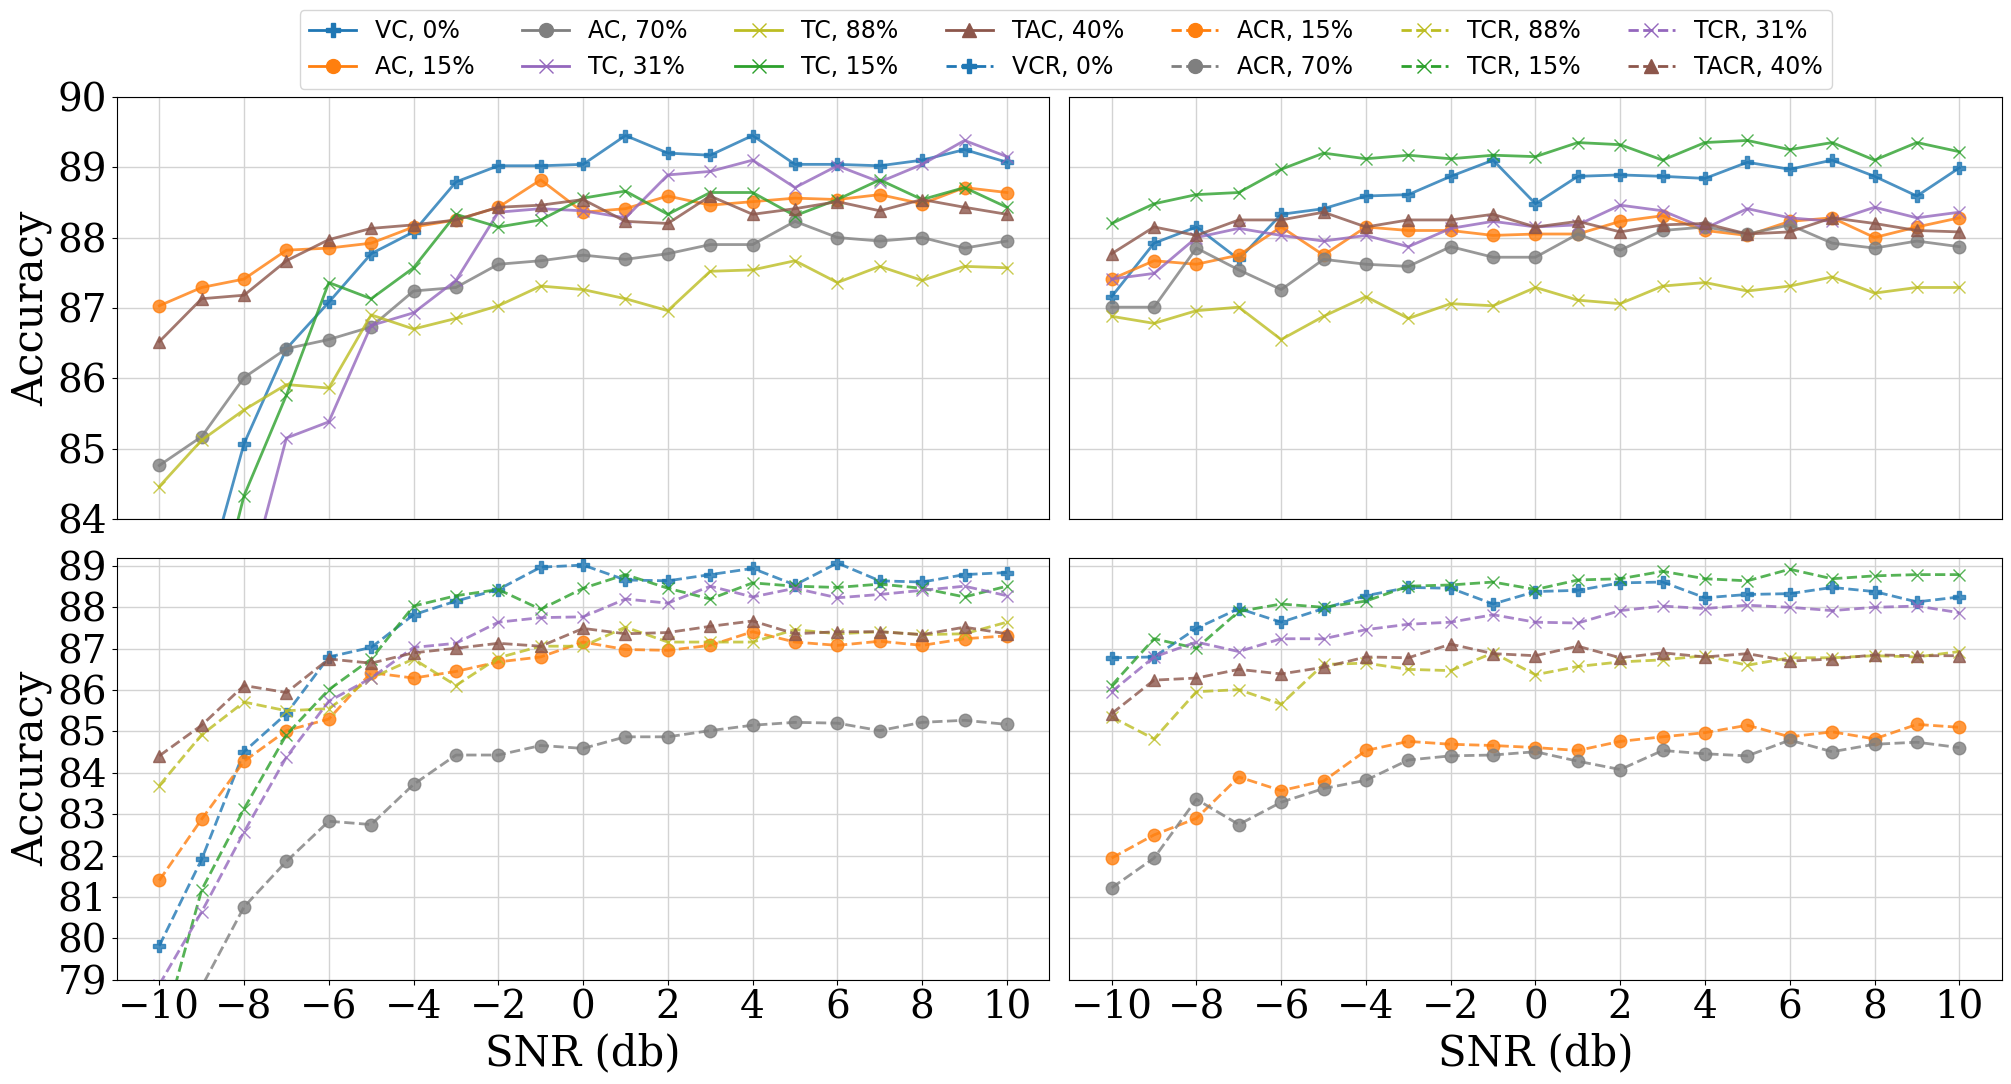

In [101]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    (0,0): {
        'VC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

        'AC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [ 15, 70,], #[ 15, 70, 88.],
        },


        'TC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 31, 88.,], #[15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
       
        'TAC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 40.,], #[24.0, 40.,],
            'compressor.use_trace_loss': [True],
    
        },
       
        },

    (0, 1): {

        'VC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

        'AC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15, 70,], #[ 15, 70,], #[ 15, 70, 88.],,
        },

        'TC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 31, 88.,], #[15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
        'TAC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           'Elements compression': [ 40.,], #[24.0, 40.,],
            'compressor.use_trace_loss': [True],
        
        },
        
        },
    (1, 0): {
        'VCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'compressor.use_trace_loss': [False]
        },
        'ACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [15., 70.,] #[15, 70, 88.]
        },
        'TCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 31.,], #[15., 88., 95.], 
            'compressor.use_trace_loss': [False],
        
        },
        'TACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'compressor.use_trace_loss': [True],
            'Elements compression': [ 40.,],#[24.0, 40.,],
        },
    },
    (1, 1): {
        
        'VCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

        'ACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           'Elements compression': [ 15., 70.,] #[ 15., 70., 88.]
        },

        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 31.,], #[15., 88., 95.], 
            'compressor.use_trace_loss': [False],
        
        },

        'TACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 40.,], #[ 24.0, 40.,], 
            'compressor.use_trace_loss': [True],
        },

    }
}



# Line styles and markers for each model
line_styles = {
    'AC': 'solid',
    'VC': 'solid',
    "ACR": 'dashed', 
   
    "TC": 'solid', 
    "TCR": 'dashed',
    "VCR": 'dashed',

    "TAC": 'solid', 
    "TACR": 'dashed', 
}

markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": '^', 
    "TACR": '^',

    'VC': 'P',
    'VCR': 'P'  
}


# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 28,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}
df_copy = df.copy()
with plt.rc_context(settings):
    fig, axs = plt.subplots(2, 2, figsize=(20, 10)) 
    final_legend_elements = []
    for ax_idx in filter_conditions.keys():
        ax = axs[ax_idx[0], ax_idx[1]]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
        
        
        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        #color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.sort_values(by=['Elements compression', 'compressor.name']).index)}

        unique_combinations_collector.fillna('NA', inplace=True)

        
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            
            if len(subset)>1:
                subset = df_copy[mask].loc[df_copy[mask].index[-1]]
                path_to_json = os.path.join(subset.path, 'results.json')
            else:   
                path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            ax.plot(
                snr.astype(int),
                accuracy,
                marker=markers[combination['compressor.name']],
                color=color_dict[idx],
                linestyle=line_styles[combination['compressor.name']],
                lw=2,
                # make the likes a bit more transparent
                alpha=0.8,
                markersize=9,
            )

            # Create legend elements
            legend_elements = [
                Line2D(
                    [0], [0], 
                    color=color_dict[idx], 
                    lw=2, 
                    linestyle=line_styles[combination['compressor.name']], 
                    marker=markers[combination['compressor.name']],
                    markersize=10, 
                    


                    label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
                ) 
                for idx, combination in unique_combinations_collector.iterrows()
            ]

        if ax_idx == (0, 0) or ax_idx == (1,0):
            final_legend_elements += legend_elements
            # Add legends to the first subplot
           # ax.legend(handles=legend_elements, ncol=3, loc='lower right')
       
    
    # Set x-ticks to integer values and adjust labels for both subplots
    for row_idx, row in enumerate(axs):
        for ax_idx, ax in enumerate(row):
            
            if row_idx == 1:
                ax.set_xticks(snr.astype(int)[::2])
                ax.set_xlabel('SNR (db)', fontsize=30)
            else:
                ax.set_xticks([])
                # Add y-axis grid lines manually
                for xtick in snr.astype(int)[::2]:
                    ax.axvline(x=xtick, color='lightgray', linestyle='-', linewidth=1, zorder=0)

            ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

            if ax_idx == 0:
                ax.set_ylabel('Accuracy', fontsize=30)
            
            step = 1
            if row_idx == 0 and ax_idx == 0:
                left, right = 84, 91
                ax.set_ylim(left,  right-1)
                ax.set_yticks(np.arange(left, right, step))
                
            elif row_idx == 0 and ax_idx == 1: 
                left, right = 84, 91
                ax.set_ylim(left,  right-1)
                ax.set_yticks([])
                ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle
                # Add y-axis grid lines manually
                for ytick in np.arange(left,  right, step):
                    ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
        
            elif row_idx == 1 and ax_idx == 0:
                left, right = 79, 90
                ax.set_ylim(left,  right-1+0.2)
                ax.set_yticks(np.arange(left, right, step))

            elif row_idx == 1 and ax_idx == 1:
                left, right = 79, 90
                ax.set_ylim(left,  right-1+0.2)
                ax.set_yticks([])  # Remove y-ticks from the second and third subplots
                ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle

                # Add y-axis grid lines manually
                for ytick in np.arange(left,  right, step):
                    ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
            
            
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=3)  # Increase space between subplots
#plot legend on top of the figure 
#fig.legend(handles=final_legend_elements, ncol=8, loc=(0, 0.95), fontsize=17)
# increase legend size 
#fig.legend(handles=final_legend_elements, ncol=8, loc='upper center', fontsize=20)
# Adjust subplots to make room for the legend at the top
plt.subplots_adjust(top=0.82)  # Adjust top margin to leave space for the legend


fig.legend(handles=final_legend_elements, ncol=7, loc='upper center', bbox_to_anchor=(0.53, 1.08), fontsize=17)
# Place the legend at the top center of the figure
# out = []
# for i, j in zip(final_legend_elements[::2], final_legend_elements[1::2]):
#     out.append(i)
#     out.append(j)
# fig.legend(handles=out, ncol=7, loc='upper center', bbox_to_anchor=(0.53, 1.08), fontsize=17)

#fig.legend(handles=final_legend_elements[:10], ncol=5, loc='upper center', bbox_to_anchor=(0.29, 1.12), fontsize=18)
#fig.legend(handles=final_legend_elements[10:], ncol=5, loc='upper center', bbox_to_anchor=(0.77, 1.12), fontsize=18)



# Save and show plot
output_pdf_path = f"performance_plot.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()

In [102]:
unique_combinations_collector

,compressor.use_trace_loss,compressor.r,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression
22,False,"[0, 0, 0, 0, 0, 0]",192,VCR,False,random,0.0
26,NA,NA,163,ACR,False,random,15.0
79,NA,NA,58,ACR,False,random,70.0
17,False,"[30, 30, 30, 30, 30, 30]",192,TCR,False,random,88.0
18,False,"[5, 5, 5, 5, 5, 5]",192,TCR,False,random,15.0
74,False,"[10, 10, 10, 10, 10, 10]",192,TCR,False,random,31.0
45,True,"[5, 5, 5, 5, 5, 5]",135,TACR,False,random,40.0


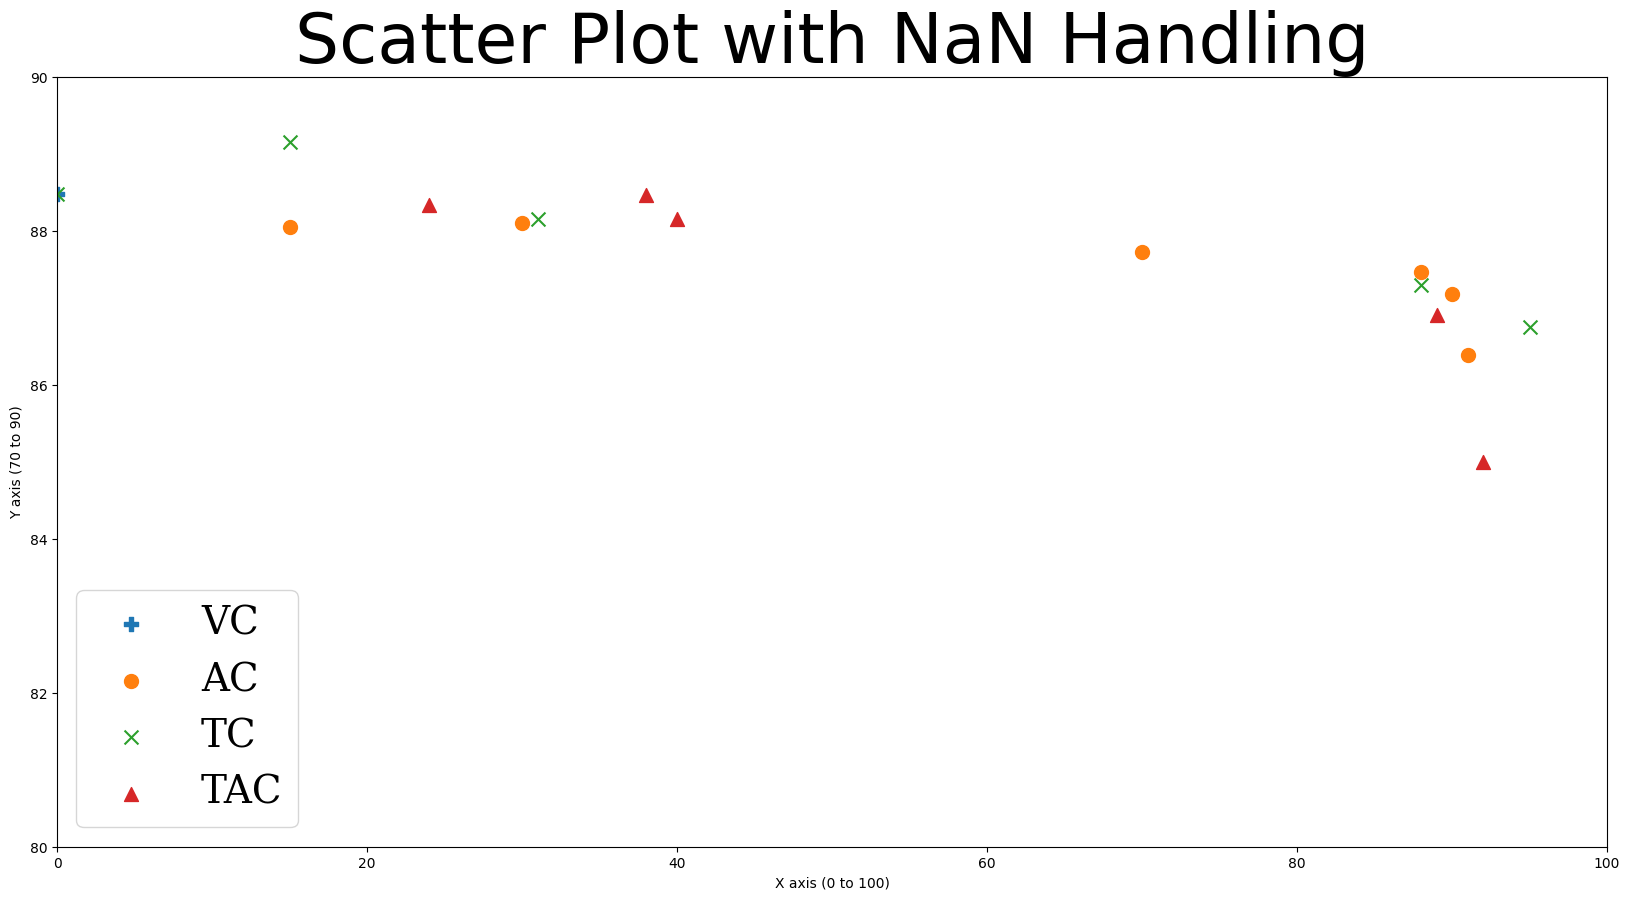

In [16]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    # (0,0): {
    #     'VC': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #         #'Elements compression': [0.0], 
    #         'compressor.use_trace_loss': [False]
    #     },

    #     'AC': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #        'Elements compression': [ 15, 70,], #[ 15, 70, 88.],
    #     },


    #     'TC': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #         'Elements compression': [15., 31, 88.,], #[15., 88., 95.], 
    #         #'compressor.use_trace_loss': [True]
    #     },
       
    #     'TAC': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #         'Elements compression': [ 40.,], #[24.0, 40.,],
    #         'compressor.use_trace_loss': [True],
    
    #     },
       
    #     },

    (0, 1): {

        'VC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

        'AC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [ 15, 70,], #[ 15, 70,], #[ 15, 70, 88.],,
        },

        'TC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [15., 31, 88.,], #[15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
        'TAC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           #'Elements compression': [ 40.,], #[24.0, 40.,],
           # 'compressor.use_trace_loss': [True],
        
        },
        
    #     },
    # (1, 0): {
    #     'VCR': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #         'compressor.use_trace_loss': [False]
    #     },
    #     'ACR': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #        'Elements compression': [15., 70.,] #[15, 70, 88.]
    #     },
    #     'TCR': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #         'Elements compression': [15., 31, 88.,], #[15., 88., 95.], 
    #         'compressor.use_trace_loss': [False],
        
    #     },
    #     'TACR': {
    #         'train_snr_db': [0], 
    #         'train_classifier_separetely': [False], 
    #         'compressor.use_trace_loss': [True],
    #         'Elements compression': [ 40.,],#[24.0, 40.,],
    #     },
    # },
    # (1, 1): {
        
    #     'VCR': {
    #         'train_snr_db': ['random'], 
    #         'train_classifier_separetely': [False], 
    #         #'Elements compression': [0.0], 
    #         #'compressor.use_trace_loss': [False]
    #     },

    #     'ACR': {
    #         'train_snr_db': ['random'], 
    #         'train_classifier_separetely': [False], 
    #        #'Elements compression': [ 15., 70.,] #[ 15., 70., 88.]
    #     },

    #     'TCR': {
    #         'train_snr_db': ['random'], 
    #         'train_classifier_separetely': [False], 
    #         #'Elements compression': [15., 31, 88.,], #[15., 88., 95.], 
    #         #'compressor.use_trace_loss': [False],
        
    #     },

    #     'TACR': {
    #         'train_snr_db': ['random'], 
    #         'train_classifier_separetely': [False], 
    #         #'Elements compression': [ 40.,], #[ 24.0, 40.,], 
    #         #'compressor.use_trace_loss': [True],
    #     },

    }
}



# Line styles and markers for each model
line_styles = {
    'AC': 'solid',
    'VC': 'solid',
    "ACR": 'dashed', 
   
    "TC": 'solid', 
    "TCR": 'dashed',
    "VCR": 'dashed',

    "TAC": 'solid', 
    "TACR": 'dashed', 
}

markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": '^', 
    "TACR": '^',

    'VC': 'P',
    'VCR': 'P'  
}


# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 28,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}
df_copy = df.copy()
fig, axs = plt.subplots(1, 1, figsize=(20, 10)) 
with plt.rc_context(settings):
    final_legend_elements = []
    for ax_idx in filter_conditions.keys():
        #ax = axs[ax_idx[0], ax_idx[1]]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
        
        
        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

        unique_combinations_collector.fillna('NA', inplace=True)
        model_compressions = defaultdict(dict)
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            
            if len(subset)>1:
                subset = df_copy[mask].loc[df_copy[mask].index[-1]]
                path_to_json = os.path.join(subset.path, 'results.json')
            else:   
                path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            
            
            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
    
            model_compressions[combination['compressor.name']][subset['Elements compression'].item()] = accuracy[10]

    
        df_scatter = pd.DataFrame(model_compressions)
        df_scatter.fillna(np.nan, inplace=True)
        for column in df_scatter.columns:
            plt.scatter(df_scatter.index, df_scatter[column], 
                        label=column,
                        marker=markers[column],
                        s=100)
        plt.xlim(0, 100)
        plt.ylim(80, 90)

        # Adding labels and title
        plt.xlabel('X axis (0 to 100)')
        plt.ylabel('Y axis (70 to 90)')
        plt.title('Scatter Plot with NaN Handling')

        # Adding the legend
        plt.legend()

        # Display the plot
        plt.show()
            

# # Recreate the DataFrame based on the provided image
# data = {'VCR': [88.097619, np.nan, np.nan, np.nan, np.nan, np.nan],
#         'ACR': [np.nan, 84.338571, 83.941429, np.nan, np.nan, np.nan],
#         'TCR': [np.nan, 88.289524, np.nan, 86.420952, 87.566190, np.nan],
#         'TACR': [np.nan, np.nan, np.nan, np.nan, np.nan, 86.675238]}
# index = [0.0, 15.0, 70.0, 88.0, 31.0, 40.0]
# df = pd.DataFrame(data, index=index)

# # Create the scatter plot
# plt.figure(figsize=(10, 6))

# Iterate over each column in the DataFrame and plot non-NaN values


# Setting the x and y axis limits

        
        
        
        #     ax.plot(
        #         snr.astype(int),
        #         accuracy,
        #         marker=markers[combination['compressor.name']],
        #         color=color_dict[idx],
        #         linestyle=line_styles[combination['compressor.name']],
        #         lw=2,
        #         # make the likes a bit more transparent
        #         alpha=0.8,
        #         markersize=9,
        #     )

        #     # Create legend elements
        #     legend_elements = [
        #         Line2D(
        #             [0], [0], 
        #             color=color_dict[idx], 
        #             lw=2, 
        #             linestyle=line_styles[combination['compressor.name']], 
        #             marker=markers[combination['compressor.name']],
        #             markersize=10, 
        #             label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
        #         ) 
        #         for idx, combination in unique_combinations_collector.iterrows()
        #     ]

        # if ax_idx == (0, 0) or ax_idx == (1,0):
        #     final_legend_elements += legend_elements
        #     # Add legends to the first subplot
        #    # ax.legend(handles=legend_elements, ncol=3, loc='lower right')

    
#     # Set x-ticks to integer values and adjust labels for both subplots
#     for row_idx, row in enumerate(axs):
#         for ax_idx, ax in enumerate(row):
            
#             if row_idx == 1:
#                 ax.set_xticks(snr.astype(int)[::2])
#                 ax.set_xlabel('SNR (db)', fontsize=30)
#             else:
#                 ax.set_xticks([])
#                 # Add y-axis grid lines manually
#                 for xtick in snr.astype(int)[::2]:
#                     ax.axvline(x=xtick, color='lightgray', linestyle='-', linewidth=1, zorder=0)

#             ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

#             if ax_idx == 0:
#                 ax.set_ylabel('Accuracy', fontsize=30)
            
#             step = 1
#             if row_idx == 0 and ax_idx == 0:
#                 left, right = 84, 91
#                 ax.set_ylim(left,  right-1)
#                 ax.set_yticks(np.arange(left, right, step))
                
#             elif row_idx == 0 and ax_idx == 1: 
#                 left, right = 84, 91
#                 ax.set_ylim(left,  right-1)
#                 ax.set_yticks([])
#                 ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle
#                 # Add y-axis grid lines manually
#                 for ytick in np.arange(left,  right, step):
#                     ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
        
#             elif row_idx == 1 and ax_idx == 0:
#                 left, right = 79, 90
#                 ax.set_ylim(left,  right-1+0.2)
#                 ax.set_yticks(np.arange(left, right, step))

#             elif row_idx == 1 and ax_idx == 1:
#                 left, right = 79, 90
#                 ax.set_ylim(left,  right-1+0.2)
#                 ax.set_yticks([])  # Remove y-ticks from the second and third subplots
#                 ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle

#                 # Add y-axis grid lines manually
#                 for ytick in np.arange(left,  right, step):
#                     ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
            
            
#     # Adjust spacing between subplots
#     plt.subplots_adjust(wspace=3)  # Increase space between subplots
# #plot legend on top of the figure 
# #fig.legend(handles=final_legend_elements, ncol=8, loc=(0, 0.95), fontsize=17)
# # increase legend size 
# #fig.legend(handles=final_legend_elements, ncol=8, loc='upper center', fontsize=20)
# # Adjust subplots to make room for the legend at the top
# plt.subplots_adjust(top=0.82)  # Adjust top margin to leave space for the legend

# # Place the legend at the top center of the figure
# fig.legend(handles=final_legend_elements, ncol=9, loc='upper center', bbox_to_anchor=(0.53, 1.1), fontsize=17)
# #fig.legend(handles=final_legend_elements[:10], ncol=5, loc='upper center', bbox_to_anchor=(0.29, 1.12), fontsize=18)
# #fig.legend(handles=final_legend_elements[10:], ncol=5, loc='upper center', bbox_to_anchor=(0.77, 1.12), fontsize=18)



# # Save and show plot
# output_pdf_path = f"performance_plot.pdf"
# plt.savefig(output_pdf_path, bbox_inches='tight')
# plt.show()

### New plot

/tmp/ipykernel_2388656/932043363.py:326: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=3)  # Increase space between subplots
/tmp/ipykernel_2388656/932043363.py:332: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.85)  # Adjust top margin to leave space for the legend


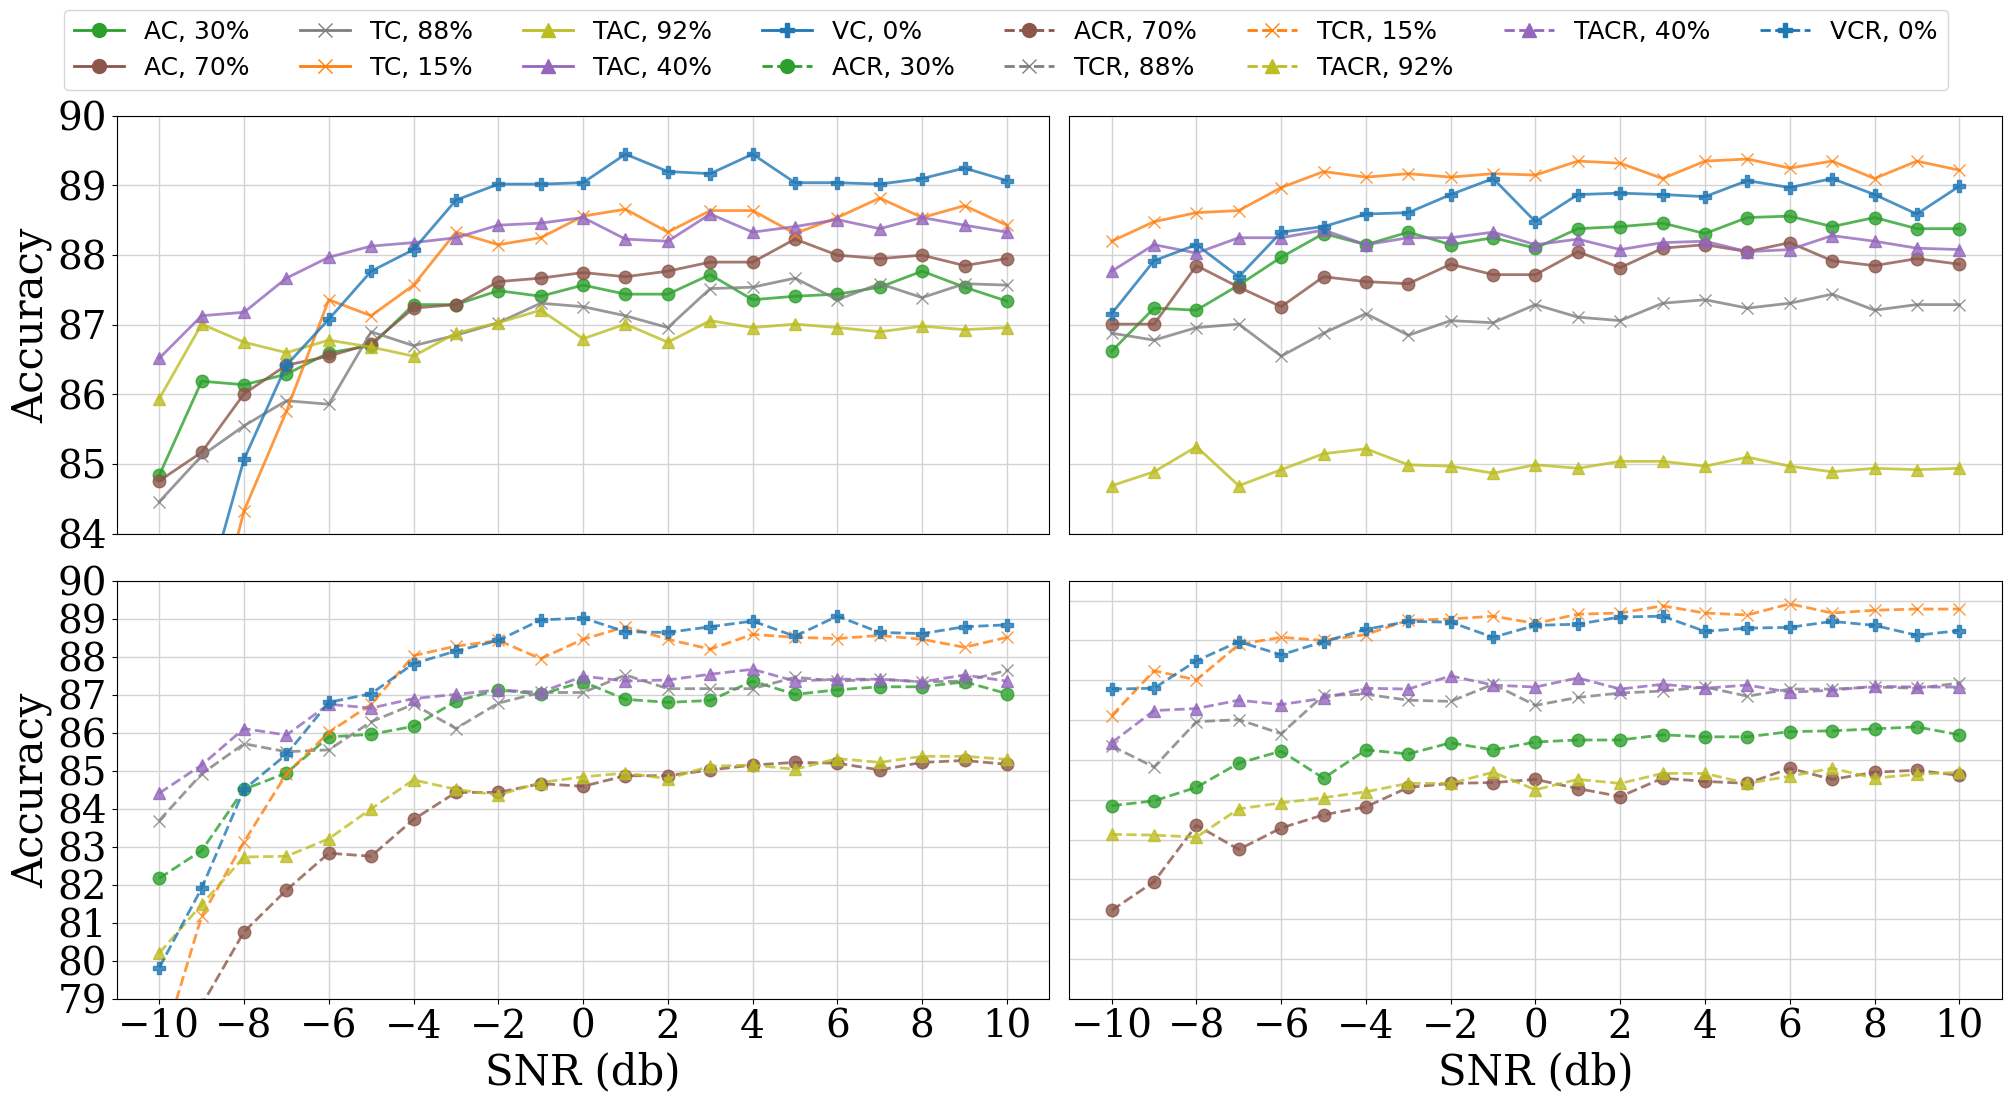

In [29]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    (0,0): {
        'AC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [70, 30]
        },


        'TC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88.,], #[15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
       
        'TAC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [92., 40.],
    
        },

        'VC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

        
       
        },

    (0, 1): {
        'AC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30],
        },

        'TC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88.,], #[15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
        'TAC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           'Elements compression': [92., 40.],
            'compressor.use_trace_loss': [True],
        
        },
        'VC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },
        
        },
    (1, 0): {
        'ACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [70, 30]
        },
        'TCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88.,], #[15., 88., 95.], 
            'compressor.use_trace_loss': [False],
        
        },

        'TACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'compressor.use_trace_loss': [True],
            'Elements compression': [92., 40.],
        },
        'VCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },
    },
    (1, 1): {
        'ACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           'Elements compression': [70, 30]
        },
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88.,], #[15., 88., 95.], 
            'compressor.use_trace_loss': [False],
        
        },

        'TACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [92., 40.], 
            'compressor.use_trace_loss': [True],
        },
        'VCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

    }
}



# Line styles and markers for each model
line_styles = {
    'AC': 'solid',
    'VC': 'solid',
    "ACR": 'dashed', 
   
    "TC": 'solid', 
    "TCR": 'dashed',
    "VCR": 'dashed',

    "TAC": 'solid', 
    "TACR": 'dashed', 
}

markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": '^', 
    "TACR": '^',

    'VC': 'P',
    'VCR': 'P'  
}


# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 28,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}
df_copy = df.copy()
with plt.rc_context(settings):
    fig, axs = plt.subplots(2, 2, figsize=(20, 10)) 
    final_legend_elements = []
    for ax_idx in filter_conditions.keys():
        ax = axs[ax_idx[0], ax_idx[1]]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
        
        
        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        #color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.sort_values(by=['Elements compression', 'compressor.name']).index)}

        unique_combinations_collector.fillna('NA', inplace=True)

        
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            
            if len(subset)>1:
                subset = df_copy[mask].loc[df_copy[mask].index[-1]]
                path_to_json = os.path.join(subset.path, 'results.json')
            else:   
                path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            ax.plot(
                snr.astype(int),
                accuracy,
                marker=markers[combination['compressor.name']],
                color=color_dict[idx],
                linestyle=line_styles[combination['compressor.name']],
                lw=2,
                # make the likes a bit more transparent
                alpha=0.8,
                markersize=9,
            )

            # Create legend elements
            legend_elements = [
                Line2D(
                    [0], [0], 
                    color=color_dict[idx], 
                    lw=2, 
                    linestyle=line_styles[combination['compressor.name']], 
                    marker=markers[combination['compressor.name']],
                    markersize=10, 
                    label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
                ) 
                for idx, combination in unique_combinations_collector.iterrows()
            ]

        if ax_idx == (0, 0) or ax_idx == (1,0):
            final_legend_elements += legend_elements
            # Add legends to the first subplot
           # ax.legend(handles=legend_elements, ncol=3, loc='lower right')
       
    
    # Set x-ticks to integer values and adjust labels for both subplots
    for row_idx, row in enumerate(axs):
        for ax_idx, ax in enumerate(row):
            
            if row_idx == 1:
                ax.set_xticks(snr.astype(int)[::2])
                ax.set_xlabel('SNR (db)', fontsize=30)
            else:
                ax.set_xticks([])
                # Add y-axis grid lines manually
                for xtick in snr.astype(int)[::2]:
                    ax.axvline(x=xtick, color='lightgray', linestyle='-', linewidth=1, zorder=0)

            ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

            if ax_idx == 0:
                ax.set_ylabel('Accuracy', fontsize=30)
            
            step = 1
            if row_idx == 0 and ax_idx == 0:
                left, right = 84, 91
                ax.set_ylim(left,  right-1)
                ax.set_yticks(np.arange(left, right, step))
                
            elif row_idx == 0 and ax_idx == 1: 
                left, right = 84, 91
                ax.set_ylim(left,  right-1)
                ax.set_yticks([])
                ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle
                # Add y-axis grid lines manually
                for ytick in np.arange(left,  right, step):
                    ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
        
            elif row_idx == 1 and ax_idx == 0:
                left, right = 79, 90.5
                ax.set_ylim(left,  right-1)
                ax.set_yticks(np.arange(left, right, step))

            elif row_idx == 1 and ax_idx == 1:
                left, right = 79, 90.5
                ax.set_ylim(left,  right-1)
                ax.set_yticks([])  # Remove y-ticks from the second and third subplots
                ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle

                # Add y-axis grid lines manually
                for ytick in np.arange(left,  right, step):
                    ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
            
            
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=3)  # Increase space between subplots
#plot legend on top of the figure 
#fig.legend(handles=final_legend_elements, ncol=8, loc=(0, 0.95), fontsize=17)
# increase legend size 
#fig.legend(handles=final_legend_elements, ncol=8, loc='upper center', fontsize=20)
# Adjust subplots to make room for the legend at the top
plt.subplots_adjust(top=0.85)  # Adjust top margin to leave space for the legend

# Place the legend at the top center of the figure
fig.legend(handles=final_legend_elements, ncol=8, loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=18)



# Save and show plot
output_pdf_path = f"performance_plot.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()

### Table

In [51]:
# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'VCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}



# Filter conditions for each model
filter_conditions = {
    0: {

        'VCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },
        'ACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [15., 30., 70.,]
        },

         'TCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15., 31, 88.], 
            'compressor.use_trace_loss': [False],
        },
       
        'TACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [40.], 
            'compressor.use_trace_loss': [False],
        
        },
        
        },
    1: {
        'VCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [0.0], 
            'compressor.use_trace_loss': [False]
        },

        'ACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15, 30., 70],
        },

        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15., 31., 88.,], 
            'compressor.use_trace_loss': [False],
        
        },

        'TACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [40.], 
            'compressor.use_trace_loss': [False],
        
        },
        
        },
}



df_copy = df.copy()

num_plots = 2

unique_combinations_collector = pd.DataFrame()
for ax_idx in range(num_plots):
    #ax = axs[ax_idx]

    ax_fc = filter_conditions[ax_idx]
    for compressor_name in ax_fc.keys():
        compressor_df = df.loc[df['compressor.name'] == compressor_name]
        sweep_columns = personalised_sweep_columns[compressor_name]
        unique_combinations = compressor_df[sweep_columns].drop_duplicates()

        # Filter according to conditions
        for condition, values in ax_fc[compressor_name].items():
            unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

        unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
    
    # Assign unique colors for each combination
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
    color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

    unique_combinations_collector.fillna('NA', inplace=True)

    unique_combinations_collector[unique_combinations_collector['compressor.name'].isin(['TVIT'])]


#snr_vals_to_keep = [-10, 0, 10]
new_df = []
for idx, combination in unique_combinations_collector.iterrows():
    selected_idx = [df_copy[key] == val for key, val in combination.items()]
    mask = np.logical_and.reduce(selected_idx)
    subset = df_copy[mask]

    if len(subset)>1:
        subset = df_copy[mask].loc[df_copy[mask].index[-1]]
        path_to_json = os.path.join(subset.path, 'results.json')
    else:   
        path_to_json = os.path.join(subset['path'].item(), 'results.json')

    # Load and plot results
    with open(path_to_json, 'r') as f:
        results = json.load(f)

    snr = np.array(list(results.keys())).astype(float)
    mse = np.array([results[key]['test/mse'] * 100 for key in results.keys()]).round(2)

    #for s,m in zip(snr, mse):
        # if (s == 0) or (s == -5) or (s == 5):
        #     new_df.append({
        #                 'snr': s, 
        #                 'mse': m,
        #                 'Model': combination['compressor.name'] + " " + str(int(combination['Elements compression'])) + '%', 
        #                 'Elements compression': combination['Elements compression'],  # Add a comma here
        #                 'train_snr_db': 'Noise' if combination['train_snr_db']=='random' else 'No Noise',

        #             })
    new_df.append({
                'snr': 'mean', 
                'mse': np.mean(np.sqrt(mse[:])).round(2),# 5:15
                'std': np.std(np.sqrt(mse[:])).round(2),
                'Model': combination['compressor.name'] + " " + str(int(combination['Elements compression'])) + '%', 
                'Elements compression': combination['Elements compression'],  # Add a comma here
                'train_snr_db': 'Noise' if combination['train_snr_db']=='random' else 'No Noise', })

    
new_df = pd.DataFrame(new_df)
#new_df['accuracy'] = new_df['accuracy_mean'].astype(str) + ' ± ' + new_df['accuracy_std'].astype(str)

#Create a pivot table and consider to have accuracy_mean +- accuracy_std
pivot_df_mean = new_df.pivot_table(
index=['Model'], 
columns=['train_snr_db', 'snr'], 
values='mse'
)

pivot_df_std = new_df.pivot_table(
index=['Model'], 
columns=['train_snr_db', 'snr'], 
values='std'
)







In [52]:
a = pivot_df_mean.loc[['VCR 0%', 'ACR 15%', 'ACR 30%', 'TCR 15%', 'TCR 31%', 'TACR 40%']].T

In [53]:
b = pivot_df_std.loc[['VCR 0%', 'ACR 15%', 'ACR 30%', 'TCR 15%', 'TCR 31%', 'TACR 40%']].T

# combine datafrranes a nd b such that a \pm b

c = a.astype(str) + ' ± ' + b.astype(str)

In [56]:
print(c.to_latex())

\begin{tabular}{llllllll}
\toprule
 & Model & VCR 0% & ACR 15% & ACR 30% & TCR 15% & TCR 31% & TACR 40% \\
train_snr_db & snr &  &  &  &  &  &  \\
\midrule
No Noise & mean & 3.68 ± 1.52 & 3.88 ± 1.15 & 3.98 ± 1.34 & 3.75 ± 1.47 & 3.85 ± 1.34 & 3.96 ± 1.25 \\
\cline{1-8}
Noise & mean & 3.72 ± 0.7 & 3.85 ± 0.73 & 4.02 ± 0.82 & 3.53 ± 0.79 & 3.64 ± 0.74 & 3.98 ± 0.73 \\
\cline{1-8}
\bottomrule
\end{tabular}



In [41]:
new_df

,snr,mse,std,Model,Elements compression,train_snr_db
0,mean,3.19,0.563242,VCR 0%,0.0,No Noise
1,mean,3.52,0.419994,ACR 15%,15.0,No Noise
2,mean,3.55,0.478544,ACR 30%,30.0,No Noise
3,mean,4.32,0.589953,ACR 70%,70.0,No Noise
4,mean,6.08,0.142269,TCR 88%,88.0,No Noise
5,mean,3.27,0.550552,TCR 15%,15.0,No Noise
6,mean,3.41,0.482181,TCR 31%,31.0,No Noise
7,mean,3.54,0.413889,TACR 40%,40.0,No Noise
8,mean,3.58,0.298574,VCR 0%,0.0,Noise
9,mean,3.68,0.304668,ACR 15%,15.0,Noise


In [48]:
unique_combinations_collector

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
39,135,ACR,False,0,30.0,NA,NA
55,58,ACR,False,0,70.0,NA,NA
59,192,TCR,False,0,95.0,False,"[40, 40, 40, 40, 40, 40]"
61,192,TCR,False,0,88.0,False,"[30, 30, 30, 30, 30, 30]"
63,192,TCR,False,0,15.0,False,"[5, 5, 5, 5, 5, 5]"
38,135,ACR,False,random,30.0,NA,NA
53,58,ACR,False,random,70.0,NA,NA
44,192,TCR,False,random,95.0,False,"[40, 40, 40, 40, 40, 40]"
46,192,TCR,False,random,88.0,False,"[30, 30, 30, 30, 30, 30]"
50,192,TCR,False,random,15.0,False,"[5, 5, 5, 5, 5, 5]"


In [44]:
new_df

,snr,mse,compressor.name,Elements compression,train_snr_db
0,0,11.14,ACR,30.0,NoNoise
1,0,16.42,ACR,70.0,NoNoise
2,0,NaN,TCR,95.0,NoNoise
3,0,NaN,TCR,88.0,NoNoise
4,0,10.03,TCR,15.0,NoNoise
5,0,NaN,TACR,92.0,NoNoise
6,0,12.76,TACR,40.0,NoNoise
7,0,13.70,ACR,30.0,Noise
8,0,17.87,ACR,70.0,Noise
9,0,NaN,TCR,95.0,Noise


In [35]:
pivot_df_mean

train_snr_db,NoNoise,Noise
Elements compression,,
15.0,17.52,16.01
30.0,17.68,16.83
40.0,19.21,16.29
70.0,26.44,22.68


In [26]:
new_df

,snr,mse_mean,mse_std,compressor.name,Elements compression,train_snr_db
0,Average,16.83,7.26,ACR,30.0,Noise
1,Average,22.68,11.49,ACR,70.0,Noise
2,Average,NaN,NaN,TCR,95.0,Noise
3,Average,NaN,NaN,TCR,88.0,Noise
4,Average,16.01,7.13,TCR,15.0,Noise
5,Average,NaN,NaN,TACR,92.0,Noise
6,Average,16.29,7.20,TACR,40.0,Noise


In [102]:
df[(df['compressor.name'] =='TAC')&(df['train_snr_db'] == 'random')]['compressor.encoding_dim']

0    135
Name: compressor.encoding_dim, dtype: int64

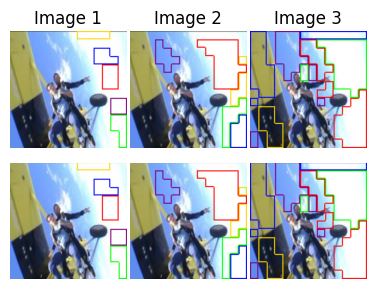

In [151]:
import glob 
path_to_images_collector = None
path_to_images=None
filter_conditions = {
    0: {
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15.], 
            'compressor.use_trace_loss': [False]
        },       
        },
    1: {
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [31.,], 
           'compressor.use_trace_loss': [False],
        },
    },
    2: {
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [88.,], 
           'compressor.use_trace_loss': [False],
        },
    },

3: {
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15.], 
            'compressor.use_trace_loss': [False]
        },       
        },
4: {
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [31.,], 
           'compressor.use_trace_loss': [False],
        },
    },
5: {
        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [88.,], 
           'compressor.use_trace_loss': [False],
        },
    },

}


num_plots = len(filter_conditions)
df_copy = df.copy()
path_to_images_collector = {}
for ax_idx in range(num_plots):
#    ax = axs[ax_idx]

    unique_combinations_collector = pd.DataFrame()
    ax_fc = filter_conditions[ax_idx]
    for compressor_name in ax_fc.keys():
        compressor_df = df.loc[df['compressor.name'] == compressor_name]
        sweep_columns = personalised_sweep_columns[compressor_name]
        unique_combinations = compressor_df[sweep_columns].drop_duplicates()

        # Filter according to conditions
        for condition, values in ax_fc[compressor_name].items():
            unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

        unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
    
    
    # Assign unique colors for each combination
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
    color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

    unique_combinations_collector.fillna('NA', inplace=True)

    
    for idx, combination in unique_combinations_collector.iterrows():
        selected_idx = [df_copy[key] == val for key, val in combination.items()]
        mask = np.logical_and.reduce(selected_idx)
        subset = df_copy[mask]

        if len(subset)>1:
            subset = df_copy[mask].loc[df_copy[mask].index[-1]]
            path_to_images = os.path.join(subset['path'], 'images/epoch_best/reconstructed/0/pergroup')
        else:   
            path_to_images = os.path.join(subset['path'].item(), 'images/epoch_best/reconstructed/0/pergroup')

        


        paths_to_images = glob.glob(path_to_images+'/*.png')
        idx = np.array([int(img.split('/')[-1].split('.')[0].split('_')[-1]) for img in paths_to_images]).argsort()
        paths_to_images = np.array(paths_to_images)[idx]
    
    path_to_images_collector[ax_idx] = paths_to_images


for i in path_to_images_collector.keys():
    path_to_images_collector[i] = path_to_images_collector[i][-1]#[2::3]


num_images = 2
new_path_to_images_collector = {0:[], 1:[]}
for row_key in range(num_images):
    if row_key == 0:
        for key in [0,1,2]:
            new_path_to_images_collector[row_key].append(path_to_images_collector[key])
    else:
        for key in [3,4,5]:
            new_path_to_images_collector[row_key].append(path_to_images_collector[key])
    
path_to_images_collector = new_path_to_images_collector




import matplotlib.pyplot as plt
from PIL import Image

def load_images(image_paths):
    """Load images from given paths and convert to RGB."""
    images = []
    for path in image_paths:
        img = Image.open(path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        images.append(img)
    return images

# Example code assuming path_to_images_collector is a dictionary
# with lists of image paths for keys 0 and 1.
for i in path_to_images_collector.keys():
    path_to_images_collector[i] = load_images(path_to_images_collector[i])
# path_to_images_collector[0] = load_images(path_to_images_collector[0])
# path_to_images_collector[1] = load_images(path_to_images_collector[1])

# Number of images
total_images = len(path_to_images_collector[0])

# Create a new figure with two rows and total_images columns
fig, axes = plt.subplots(
    len(path_to_images_collector),
    total_images,
    figsize=(12, 3),
    #gridspec_kw={'hspace': -0.4}
    )
for row, key in enumerate(path_to_images_collector.keys()):
    if row == 0:
        # Plot images from key 0 in the first row
        for img_idx in range(total_images):
            axes[0, img_idx].imshow(path_to_images_collector[key][img_idx])
            axes[0, img_idx].axis('off')  # Turn off axis labels
            axes[0, img_idx].set_title(f"Image {img_idx + 1}")
    else:
        # Plot images from key 1 in the second row
        for img_idx in range(total_images):
            axes[row, img_idx].imshow(path_to_images_collector[key][img_idx])
            axes[row, img_idx].axis('off')  # Turn off axis labels
    # Add a space between rows
    #plt.subplots_adjust(hspace=0.1)

# Adjust the spacing to reduce the gap between rows
plt.subplots_adjust(wspace=-1,)

plt.tight_layout()
output_pdf_path = f"groups.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()


In [148]:

num_images = 2
new_path_to_images_collector = {0:[], 1:[]}
for row_key in range(num_images):
    if row_key == 0:
        for key in [0,1,2]:
            new_path_to_images_collector[row_key].append(path_to_images_collector[i])
    else:
        for key in [3,4,5]:
            new_path_to_images_collector[row_key].append(path_to_images_collector[i])

In [149]:
new_path_to_images_collector

{0: ['log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
  'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
  'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png'],
 1: ['log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
  'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
  'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png']}

In [150]:
path_to_images_collector

{0: 'log/runs/2024-09-05-23-59-47/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 1: 'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 2: 'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 3: 'log/runs/2024-09-05-23-59-47/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 4: 'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 5: 'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png'}

In [137]:
num_images


2

In [135]:
path_to_images_collector

{0: 'log/runs/2024-09-05-23-59-47/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 1: 'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_3920.png',
 2: 'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3920.png'}

In [61]:
total_images

5

In [60]:
path_to_images_collector

{0: array(['log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_392.png',
        'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_1176.png',
        'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_1960.png',
        'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_2744.png',
        'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_3528.png'],
       dtype='<U86'),
 1: array(['log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_392.png',
        'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_1176.png',
        'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_1960.png',
        'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_2744.png',
        'log/runs/2024-09-06-01-18-43/images/epoch_best/reconstructed/0/pergroup/image_3528

In [54]:
path_to_images_collector[0][img_idx]

'log/runs/2024-09-06-00-40-50/images/epoch_best/reconstructed/0/pergroup/image_1176.png'

In [50]:
filter_conditions

{0: {'TCR': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False],
   'Elements compression': [31.0],
   'compressor.use_trace_loss': [False]}},
 1: {'TCR': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False],
   'Elements compression': [88.0],
   'compressor.use_trace_loss': [False]}},
 2: {'TACR': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False],
   'Elements compression': [40.0],
   'compressor.use_trace_loss': [False]}}}

In [46]:
filter_conditions

{0: {'TCR': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False],
   'Elements compression': [31.0],
   'compressor.use_trace_loss': [False]}},
 1: {'TCR': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False],
   'Elements compression': [88.0],
   'compressor.use_trace_loss': [False]}},
 2: {'TACR': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False],
   'Elements compression': [40.0],
   'compressor.use_trace_loss': [False]}}}

In [28]:
path_to_images = os.path.join(subset['path'].item(), 'images/epoch_best/reconstructed/0/pergroup')

In [29]:
paths_to_images = glob.glob(path_to_images+'/*.png')

In [85]:
path_to_images_collector


{0: [], 1: []}

In [60]:
path_to_images_collector

{0: [<PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>,
  <PIL.Image.Image image mode=RGB size=500x500>],
 1: []}

In [66]:
unique_combinations_collector

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
11,135.0,ACRVIT,False,0,30.0,NA,NA
27,58.0,ACRVIT,False,0,70.0,NA,NA
37,NA,TCVIT,False,0,0.0,False,"[0, 0, 0, 0, 0, 0]"
41,NA,TCVIT,False,0,95.0,False,"[40, 40, 40, 40, 40, 40]"
42,NA,TCVIT,False,0,88.0,False,"[30, 30, 30, 30, 30, 30]"
43,NA,TCVIT,False,0,15.0,False,"[5, 5, 5, 5, 5, 5]"
24,NA,TCRVIT,False,0,95.0,True,"[40, 40, 40, 40, 40, 40]"
26,NA,TCRVIT,False,0,88.0,True,"[30, 30, 30, 30, 30, 30]"
29,NA,TCRVIT,False,0,15.0,True,"[5, 5, 5, 5, 5, 5]"


30    TCVIT
32    TCVIT
36    TCVIT
37    TCVIT
38    TCVIT
39    TCVIT
40    TCVIT
41    TCVIT
42    TCVIT
43    TCVIT
Name: compressor.name, dtype: object

In [149]:
df[df['compressor.name'] == 'TCRVIT']['compressor.r']

1    [10, 10, 10, 10, 10, 10]
2          [5, 5, 5, 5, 5, 5]
Name: compressor.r, dtype: object

In [ ]:
mask

array([False, False, False, False, False])

In [ ]:
subset['path']

Series([], Name: path, dtype: object)

In [ ]:
snr

NameError: name 'snr' is not defined

In [ ]:
results

defaultdict(dict, {})

In [ ]:
unique_combinations_collector

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r


### Table 

In [27]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACRVIT': ['compressor.encoding_dim'] + shared_sweep_columns,
    'TVIT': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,
    'PCAVIT': ['compressor.q'] + shared_sweep_columns,
    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    0: {
       
        'TVIT': {
            'train_snr_db': [0, 'random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [15., 31.,66., 88., 95.], 
            'compressor.use_trace_loss': [True, False]
        },
       
        },
    1: {
        'ACRVIT': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 40, 10]
        },
        'TVIT': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 31., 88., 95.], 
            'compressor.use_trace_loss': [True]
        },
        'VIT': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [0]
        }},
    2: {
        # 'ACRVIT': {
        #     'train_snr_db': [0], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [70, 40, 10]
        # },
        'TVIT': {
            'train_snr_db': ['random', 0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15,  88.],  # 88., 95.
            'compressor.use_trace_loss': [True, False]
        },
        
        'VIT': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [0]
        }},
}


df_copy = df.copy()

num_plots = 1

for ax_idx in range(num_plots):
    ax = axs[ax_idx]

    unique_combinations_collector = pd.DataFrame()
    ax_fc = filter_conditions[ax_idx]
    for compressor_name in ax_fc.keys():
        compressor_df = df.loc[df['compressor.name'] == compressor_name]
        sweep_columns = personalised_sweep_columns[compressor_name]
        unique_combinations = compressor_df[sweep_columns].drop_duplicates()

        # Filter according to conditions
        for condition, values in ax_fc[compressor_name].items():
            unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

        unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
    
    # def update_name(row):
    #     if row['compressor.use_trace_loss']==False and row['compressor.name'] == 'TVIT':
    #         return 'No Trace Loss'
    #     return 'Trace Loss'
    # Apply the function to the DataFrame
    #unique_combinations_collector['compressor.name'] = unique_combinations_collector.apply(update_name, axis=1)
    #df_copy['compressor.name'] = df_copy.apply(update_name, axis=1)

    # Assign unique colors for each combination
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
    
    #color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.sort_values(by=['Elements compression', 'compressor.name']).index)}

    unique_combinations_collector.fillna('NA', inplace=True)

    unique_combinations_collector[unique_combinations_collector['compressor.name'].isin(['TVIT'])]


snr_vals_to_keep = [-10, 0, 10]
new_df = []
for idx, combination in unique_combinations_collector.iterrows():
    selected_idx = [df_copy[key] == val for key, val in combination.items()]
    mask = np.logical_and.reduce(selected_idx)
    subset = df_copy[mask]
    path_to_json = os.path.join(subset['path'].item(), 'results.json')

    # Load and plot results
    with open(path_to_json, 'r') as f:
        results = json.load(f)

    snr = np.array(list(results.keys())).astype(float)
    accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)

   
    new_df.append({
                'snr': 'Average', 
                'accuracy_mean': np.round(accuracy.mean(),2),
                'accuracy_std': np.round(accuracy.std(),2), #f'{accuracy.mean()} ± {accuracy.std()}', 
                'compressor.name': combination['compressor.name'], 
                'compressor.use_trace_loss': combination['compressor.use_trace_loss'],
                'Elements compression': combination['Elements compression'],  # Add a comma here
                'train_snr_db': 'Noise' if combination['train_snr_db']=='random' else 'NoNoise',
            })
    
    # for s,acc in zip(snr, accuracy):
        # if s in snr_vals_to_keep:
        #     new_df.append({
        #         'snr': s, 
        #         'accuracy': acc, 
        #         'compressor.name': combination['compressor.name'], 
        #         'compressor.use_trace_loss': combination['compressor.use_trace_loss'],
        #         'Elements compression': combination['Elements compression'],  # Add a comma here
        #         'train_snr_db': 'Noise' if combination['train_snr_db']=='random' else 'NoNoise',
        #     })

new_df = pd.DataFrame(new_df)
#new_df['accuracy'] = new_df['accuracy_mean'].astype(str) + ' ± ' + new_df['accuracy_std'].astype(str)

#Create a pivot table and consider to have accuracy_mean +- accuracy_std
pivot_df_mean = new_df.pivot_table(
    index=['Elements compression'], 
    columns=['train_snr_db', 'compressor.use_trace_loss'], 
    values='accuracy_mean'
)

pivot_df_std = new_df.pivot_table(
    index=['Elements compression', 'snr'], 
    columns=['train_snr_db', 'compressor.name'], 
    values='accuracy_std'
)




# # Create a pivot table
# pivot_df = new_df.pivot_table(
#     index=['Elements compression', 'snr'], 
#     columns=['train_snr_db', 'compressor.name'], 
#     values='accuracy'
# )



KeyError: 'accuracy_mean'

,compressor.use_trace_loss,compressor.r,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression
25,False,"[0, 0, 0, 0, 0, 0]",192,VC,False,0,0.0
29,NA,NA,163,AC,False,0,15.0
97,False,"[5, 5, 5, 5, 5, 5]",192,TC,False,0,15.0
86,False,"[10, 10, 10, 10, 10, 10]",192,TC,False,0,31.0
41,True,"[5, 5, 5, 5, 5, 5]",135,TAC,False,0,40.0
53,NA,NA,58,AC,False,0,70.0
96,False,"[30, 30, 30, 30, 30, 30]",192,TC,False,0,88.0


,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
0,192.0,AEVIT,False,random,0.0,NA,NA
1,192.0,AEVIT,False,0,0.0,NA,NA
2,173.0,AEVIT,False,random,10.0,NA,NA
4,173.0,AEVIT,False,0,10.0,NA,NA
6,154.0,AEVIT,False,random,20.0,NA,NA
8,154.0,AEVIT,False,0,20.0,NA,NA
10,135.0,AEVIT,False,random,30.0,NA,NA
11,135.0,AEVIT,False,0,30.0,NA,NA
13,116.0,AEVIT,False,random,40.0,NA,NA
15,116.0,AEVIT,False,0,40.0,NA,NA


In [33]:
selected_idx[0]

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
Name: compressor.encoding_dim, dtype: bool

In [ ]:
df['experiments_dir']


0    log/runs/
1    log/runs/
2    log/runs/
3    log/runs/
4    log/runs/
5    log/runs/
6    log/runs/
Name: experiments_dir, dtype: object

In [ ]:
# Data frame from list of dictionaries


In [137]:
# read this /home/lev/projects_6g/peekvit/log/runs/2024-09-07-19-20-07/results.json

# Load and plot results
with open('/home/lev/projects_6g/peekvit/log/runs/2024-09-07-19-20-07/results.json', 'r') as f:
    results = json.load(f)

In [138]:
[10.48, 12.60, 12.84, 10.98, 11.86, 12.73]

{'-10': {'test/mse': nan,
  'test/classification_loss': 0.5922406335030833,
  'test/accuracy': 0.8282802700996399,
  'test/loss': nan},
 '-9': {'test/mse': nan,
  'test/classification_loss': 0.5798860942163775,
  'test/accuracy': 0.831337571144104,
  'test/loss': nan},
 '-8': {'test/mse': nan,
  'test/classification_loss': 0.5776211254058345,
  'test/accuracy': 0.8397452235221863,
  'test/loss': nan},
 '-7': {'test/mse': nan,
  'test/classification_loss': 0.5708080914712721,
  'test/accuracy': 0.8453503251075745,
  'test/loss': nan},
 '-6': {'test/mse': nan,
  'test/classification_loss': 0.5802927805531409,
  'test/accuracy': 0.8428025245666504,
  'test/loss': nan},
 '-5': {'test/mse': nan,
  'test/classification_loss': 0.5766821196002345,
  'test/accuracy': 0.8478980660438538,
  'test/loss': nan},
 '-4': {'test/mse': nan,
  'test/classification_loss': 0.5913747991285017,
  'test/accuracy': 0.8484076261520386,
  'test/loss': nan},
 '-3': {'test/mse': nan,
  'test/classification_loss': 